In [6]:
import pandas as pd

# Load the cleaned CBE reviews CSV
cbe_df = pd.read_csv("../data/processed/commercial_bank_of_ethiopia_cleaned_reviews.csv")

# Display basic info and first few rows
print("Shape:", cbe_df.shape)
print(cbe_df.columns)
cbe_df.head()


Shape: (414, 5)
Index(['review', 'rating', 'date', 'bank', 'source'], dtype='object')


,review,rating,date,bank,source
0,More than garrantty bank EBC.,4,2025-06-07,Commercial Bank of Ethiopia,Google Play
1,really am happy to this app it is Siple to use...,5,2025-06-07,Commercial Bank of Ethiopia,Google Play
2,I liked this app. But the User interface is ve...,2,2025-06-07,Commercial Bank of Ethiopia,Google Play
3,"""Why don’t your ATMs support account-to-accoun...",4,2025-06-06,Commercial Bank of Ethiopia,Google Play
4,what is this app problem???,1,2025-06-05,Commercial Bank of Ethiopia,Google Play


In [7]:
print(cbe_df.columns)

Index(['review', 'rating', 'date', 'bank', 'source'], dtype='object')


In [8]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary resources (only needed once)
nltk.download('punkt')
nltk.download('stopwords')

# Define stopwords
stop_words = set(stopwords.words('english'))

# Define a preprocessing function
def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove digits and punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(filtered_tokens)

# Apply preprocessing to a new column
cbe_df['cleaned_review'] = cbe_df['review'].astype(str).apply(preprocess_text)

# Preview
cbe_df[['review', 'cleaned_review']].head()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,cleaned_review
0,More than garrantty bank EBC.,garrantty bank ebc
1,really am happy to this app it is Siple to use...,really happy app siple use everything
2,I liked this app. But the User interface is ve...,liked app user interface basic attractive
3,"""Why don’t your ATMs support account-to-accoun...",dont atms support accounttoaccount transfers l...
4,what is this app problem???,app problem


In [10]:

import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import string

# Combine stopwords from nltk and punctuation
stop_words = set(stopwords.words('english') + list(string.punctuation))

# Define a preprocessing function for TF-IDF
def preprocess_text(text):
    tokens = text.lower().split()
    tokens = [word for word in tokens if word not in stop_words and word.isalpha()]
    return ' '.join(tokens)

# Apply preprocessing
cbe_df['clean_review'] = cbe_df['review'].astype(str).apply(preprocess_text)

# Run TF-IDF
vectorizer = TfidfVectorizer(max_features=30, ngram_range=(1, 2))
X = vectorizer.fit_transform(cbe_df['clean_review'])

# Extract top TF-IDF keywords
tfidf_keywords = vectorizer.get_feature_names_out()
print("Top TF-IDF Keywords:")
print(tfidf_keywords)


Top TF-IDF Keywords:
['app' 'application' 'apps' 'bank' 'banking' 'best' 'cbe' 'developer'
 'easy' 'fix' 'good' 'good app' 'great' 'like' 'make' 'mobile'
 'mobile banking' 'money' 'need' 'nice' 'one' 'please' 'screenshot'
 'simple' 'thank' 'time' 'transaction' 'update' 'use' 'work']


In [11]:
import spacy
from collections import Counter

# Load English spaCy model
nlp = spacy.load("en_core_web_sm")

# Function to extract noun chunks
def extract_noun_chunks(text):
    doc = nlp(text)
    return [chunk.text.lower() for chunk in doc.noun_chunks if len(chunk.text.split()) > 1]

# Apply to all reviews
cbe_df['noun_chunks'] = cbe_df['review'].astype(str).apply(extract_noun_chunks)

# Flatten and count most common noun chunks
all_chunks = [chunk for sublist in cbe_df['noun_chunks'] for chunk in sublist]
chunk_counts = Counter(all_chunks)
top_chunks = chunk_counts.most_common(20)

print("Top Noun Phrases (spaCy):")
for phrase, count in top_chunks:
    print(f"{phrase}: {count}")


Top Noun Phrases (spaCy):
this app: 41
the app: 38
good app: 9
the screenshot: 8
very good app: 7
best app: 6
the bank: 5
this application: 5
cbe app: 5
great app: 5
a bug: 5
my money: 4
mobile banking: 4
the developer: 3
the system: 3
the receipt: 3
developer mode: 3
developer options: 3
its good: 3
the best app: 3


In [12]:
# Define themes and their keywords
themes = {
    "Login Issues": ["login", "sign in", "account access", "password"],
    "Transaction Problems": ["transfer", "transaction", "delay", "failed", "crash"],
    "App Usability": ["interface", "user friendly", "app design", "easy to use"],
    "Customer Support": ["support", "help", "contact"],
    "Positive Feedback": ["great", "good", "excellent", "love", "smooth", "helpful"]
}

# Function to assign themes to a review
def identify_themes(text):
    found_themes = []
    for theme, keywords in themes.items():
        for keyword in keywords:
            if keyword in text.lower():
                found_themes.append(theme)
                break  # avoid duplicate theme assignment
    return found_themes if found_themes else ["Other"]

# Apply function
cbe_df['themes'] = cbe_df['review'].astype(str).apply(identify_themes)

# Show sample
cbe_df[['review', 'themes']].head(10)


,review,themes
0,More than garrantty bank EBC.,[Other]
1,really am happy to this app it is Siple to use...,[Other]
2,I liked this app. But the User interface is ve...,[App Usability]
3,"""Why don’t your ATMs support account-to-accoun...","[Transaction Problems, Customer Support]"
4,what is this app problem???,[Other]
5,the app is proactive and a good connections.,[Positive Feedback]
6,I cannot send to cbebirr app. through this app.,[Other]
7,not functional,[Other]
8,everytime you uninstall the app you have to re...,[Other]
9,it was good app but it have some issues like i...,"[Transaction Problems, Positive Feedback]"


C:\Users\PC\AppData\Local\Temp\ipykernel_13544\1263765382.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=theme_df, x='count', y='theme', palette='viridis')


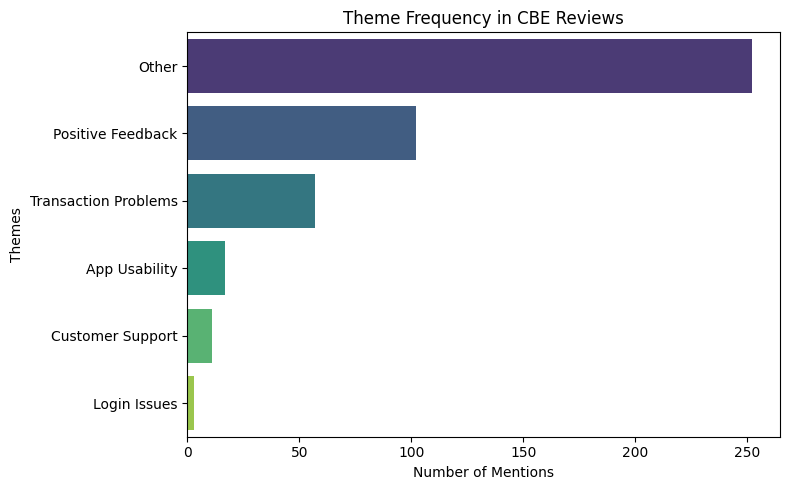

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Flatten all themes into a single list
all_themes = [theme for sublist in cbe_df['themes'] for theme in sublist]
theme_counts = Counter(all_themes)

# Convert to DataFrame
theme_df = pd.DataFrame.from_dict(theme_counts, orient='index', columns=['count']).reset_index()
theme_df.columns = ['theme', 'count']
theme_df = theme_df.sort_values(by='count', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=theme_df, x='count', y='theme', palette='viridis')
plt.title("Theme Frequency in CBE Reviews")
plt.xlabel("Number of Mentions")
plt.ylabel("Themes")
plt.tight_layout()
plt.show()


In [14]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

# Initialize VADER
sid = SentimentIntensityAnalyzer()

# Analyze sentiment for each review
sentiment_labels = []
sentiment_scores = []

for review in tqdm(cbe_df['review']):
    score = sid.polarity_scores(str(review))['compound']
    sentiment_scores.append(score)

    if score >= 0.05:
        sentiment_labels.append('positive')
    elif score <= -0.05:
        sentiment_labels.append('negative')
    else:
        sentiment_labels.append('neutral')

# Create sentiment_results DataFrame
sentiment_results = pd.DataFrame({
    'sentiment': sentiment_labels,
    'sentiment_score': sentiment_scores
})

# Attach it to cbe_df
cbe_df = cbe_df.reset_index(drop=True)
sentiment_results = sentiment_results.reset_index(drop=True)

cbe_df['sentiment'] = sentiment_results['sentiment']
cbe_df['sentiment_score'] = sentiment_results['sentiment_score']

print("✅ Sentiment scores added!")


  0%|          | 0/414 [00:00<?, ?it/s]

✅ Sentiment scores added!


In [15]:
# Select columns to save
final_df = cbe_df[['review', 'rating', 'date', 'sentiment', 'sentiment_score', 'themes']]

# Save to CSV
final_df.to_csv("cbe_sentiment_themes.csv", index=False)

print("✅ Saved to cbe_sentiment_themes.csv")


✅ Saved to cbe_sentiment_themes.csv


In [16]:
print(cbe_df.columns)


Index(['review', 'rating', 'date', 'bank', 'source', 'cleaned_review',
       'clean_review', 'noun_chunks', 'themes', 'sentiment',
       'sentiment_score'],
      dtype='object')


In [17]:
# Ensure sentiment_results exists and matches cbe_df
cbe_df = cbe_df.reset_index(drop=True)
sentiment_results = sentiment_results.reset_index(drop=True)

# Add the sentiment and score columns to cbe_df
cbe_df['sentiment'] = sentiment_results['sentiment']
cbe_df['sentiment_score'] = sentiment_results['sentiment_score']


In [18]:
# Save processed CBE data with sentiment and themes
output_path = "processed_cbe_data_with_sentiment_reviews.csv"
cbe_df.to_csv(output_path, index=False)
print(f"✅ Data saved to {output_path}")



✅ Data saved to processed_cbe_data_with_sentiment_reviews.csv
